In [2]:
# Core
import os
import re
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import joblib

# Boosting (optional)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("XGBoost not installed")

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except ImportError:
    LGBM_AVAILABLE = False
    print("LightGBM not installed")

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Settings
RANDOM_STATE = 42
TFIDF_MAX_FEATURES = 50000

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings("ignore")

print("Setup done")

Setup done


In [3]:
FAKE_CSV_PATH = "Fake.csv"
TRUE_CSV_PATH = "True.csv"

LABEL_COL   = "label"
CLASS_NAMES = {0: "FAKE", 1: "REAL"}


def load_dataset(fake_path, true_path):
    fake_df = pd.read_csv(fake_path)
    true_df = pd.read_csv(true_path)

    fake_df[LABEL_COL] = 0
    true_df[LABEL_COL] = 1

    df = pd.concat([fake_df, true_df], ignore_index=True)
    df = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

    return df


# Load data
df = load_dataset(FAKE_CSV_PATH, TRUE_CSV_PATH)

# Combine title + text
df["title"] = df["title"].fillna("")
df["text"]  = df["text"].fillna("")
df["content"] = df["title"] + " " + df["text"]

TEXT_COL = "content"

# Remove duplicates
before = len(df)
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)
after = len(df)

print(f"Data shape: {df.shape}")
print(f"Duplicates removed: {before - after}")

# Label distribution
print("\nLabel distribution:")
print(df[LABEL_COL].value_counts(normalize=True))

Data shape: (39105, 6)
Duplicates removed: 5793

Label distribution:
label
1    0.542053
0    0.457947
Name: proportion, dtype: float64


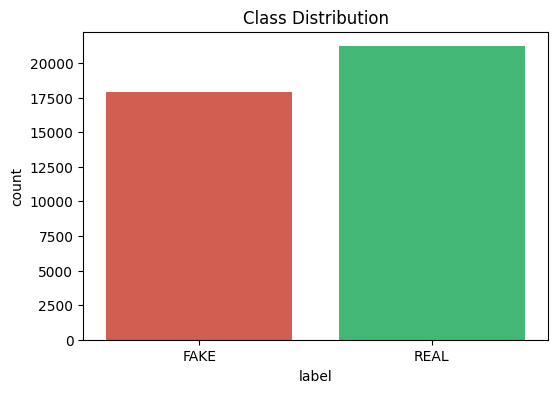

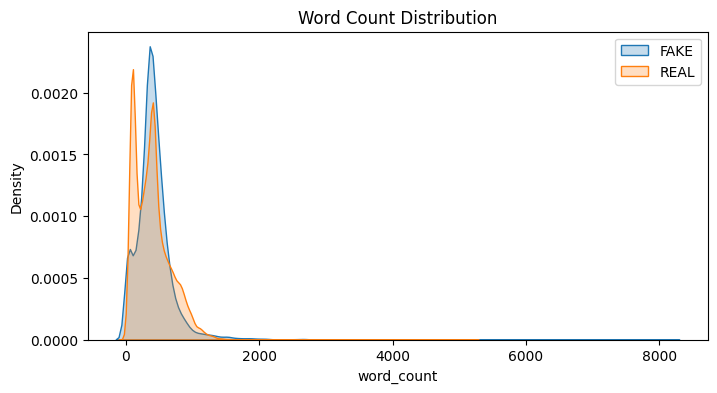

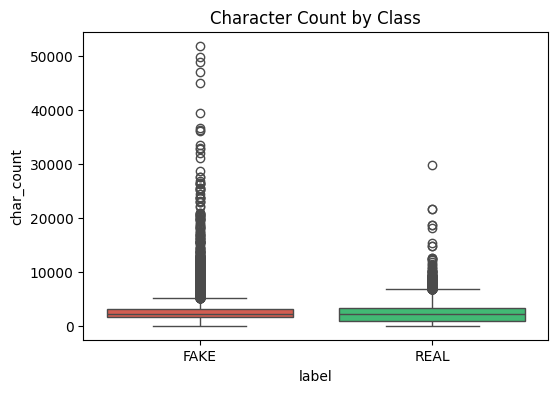

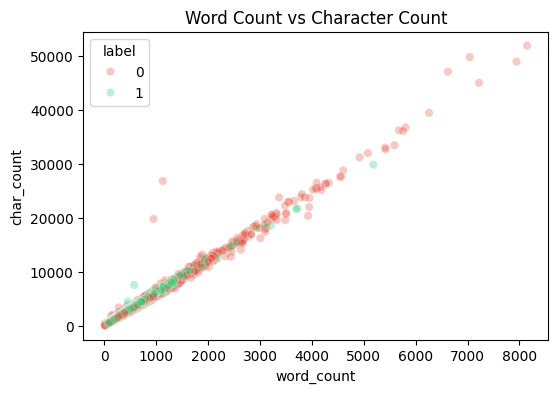

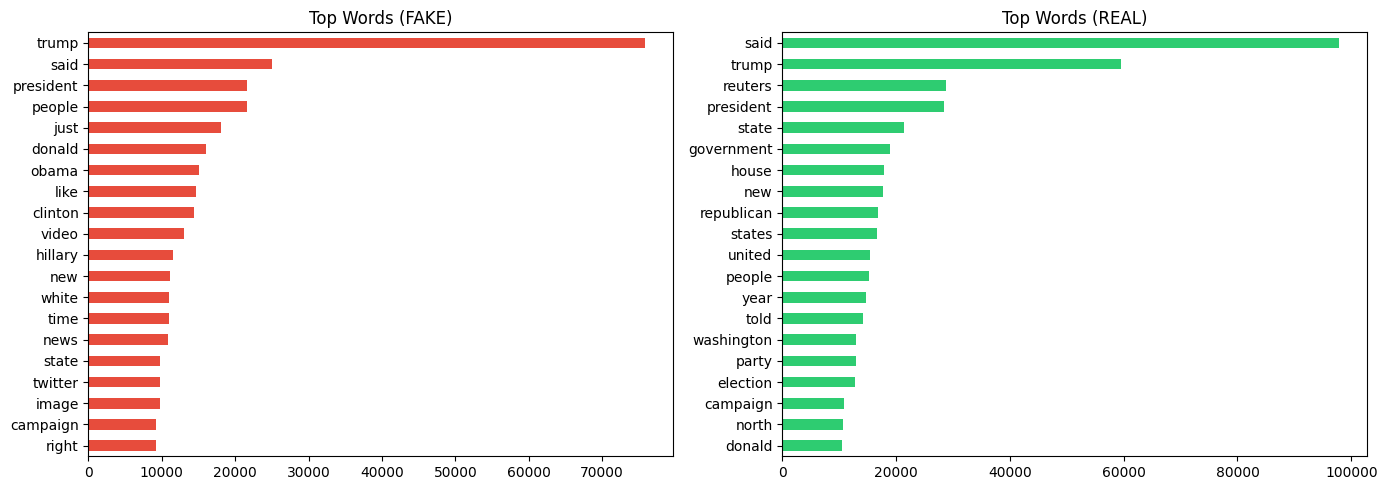

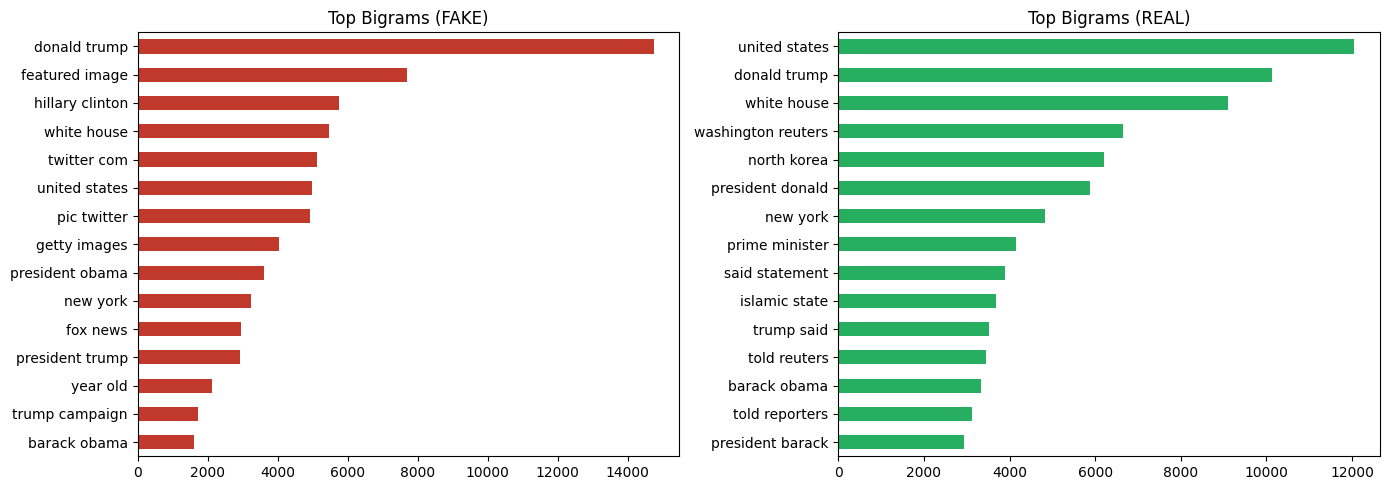

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer

# Basic stats
df["word_count"] = df[TEXT_COL].apply(lambda x: len(str(x).split()))
df["char_count"] = df[TEXT_COL].apply(len)

FAKE_MASK = df[LABEL_COL] == 0
REAL_MASK = df[LABEL_COL] == 1

# ── 1. Class distribution ──
plt.figure(figsize=(6, 4))
sns.countplot(x=LABEL_COL, data=df, palette=["#e74c3c", "#2ecc71"])
plt.title("Class Distribution")
plt.xticks([0, 1], ["FAKE", "REAL"])
plt.show()

# ── 2. Word count distribution ──
plt.figure(figsize=(8, 4))
sns.kdeplot(df.loc[FAKE_MASK, "word_count"], label="FAKE", fill=True)
sns.kdeplot(df.loc[REAL_MASK, "word_count"], label="REAL", fill=True)
plt.title("Word Count Distribution")
plt.legend()
plt.show()

# ── 3. Character count boxplot ──
plt.figure(figsize=(6, 4))
sns.boxplot(x=df[LABEL_COL], y=df["char_count"], palette=["#e74c3c", "#2ecc71"])
plt.title("Character Count by Class")
plt.xticks([0, 1], ["FAKE", "REAL"])
plt.show()

# ── 4. Word vs Character relationship ──
plt.figure(figsize=(6, 4))
sns.scatterplot(
    x=df["word_count"],
    y=df["char_count"],
    hue=df[LABEL_COL],
    palette=["#e74c3c", "#2ecc71"],
    alpha=0.3
)
plt.title("Word Count vs Character Count")
plt.show()

# ── 5. Top words ──
def get_top_words(corpus, n=20):
    vec = CountVectorizer(stop_words="english", max_features=50000)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    return pd.Series(counts, index=words).sort_values(ascending=False).head(n)

fake_top = get_top_words(df.loc[FAKE_MASK, TEXT_COL])
real_top = get_top_words(df.loc[REAL_MASK, TEXT_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_top[::-1].plot(kind="barh", ax=axes[0], color="#e74c3c")
axes[0].set_title("Top Words (FAKE)")

real_top[::-1].plot(kind="barh", ax=axes[1], color="#2ecc71")
axes[1].set_title("Top Words (REAL)")

plt.tight_layout()
plt.show()

# ── 6. Bigram comparison ──
def get_top_bigrams(corpus, n=15):
    vec = CountVectorizer(ngram_range=(2, 2), stop_words="english", max_features=50000)
    X = vec.fit_transform(corpus)
    counts = X.sum(axis=0).A1
    words = vec.get_feature_names_out()
    return pd.Series(counts, index=words).sort_values(ascending=False).head(n)

fake_bi = get_top_bigrams(df.loc[FAKE_MASK, TEXT_COL])
real_bi = get_top_bigrams(df.loc[REAL_MASK, TEXT_COL])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_bi[::-1].plot(kind="barh", ax=axes[0], color="#c0392b")
axes[0].set_title("Top Bigrams (FAKE)")

real_bi[::-1].plot(kind="barh", ax=axes[1], color="#27ae60")
axes[1].set_title("Top Bigrams (REAL)")

plt.tight_layout()
plt.show()

In [6]:
# Split data
X = df[TEXT_COL]
y = df[LABEL_COL]

# Test split
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE
)

# Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # 15% of total
    stratify=y_temp,
    random_state=RANDOM_STATE
)

# Basic info
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

# Check no overlap
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

print("Splits ready")

Train: (27372,)
Val  : (5867,)
Test : (5866,)
Splits ready
